In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px

In [106]:
df = pd.read_csv("disaster.csv")
df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN
1,2,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,3,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,1.0,4.0,1.0,3.0,6.0,5.0,2.0,5.0,2.0,5.0
3,4,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,4.0,NaN,2.0,1.0,1.0,1.0,1.0,1.0,NaN,2.0
4,5,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [107]:
df[df["CTS Name"].isnull()]

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
7,8,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,NaN,NaN,NaN,13500000.0,NaN,NaN,11000000.0,NaN,NaN,NaN
8,9,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,327422.0
9,10,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,3010.0,0.0,1822.0,4000.0,130942.0,44076.0,35033.0,266787.0,127549.0,312504.0
10,11,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,33707.0,NaN,363.0,0.0,0.0,260.0,0.0,0.0,NaN,158.0
11,12,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,NaN,NaN,9055.0,NaN,NaN,7481.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,2888,Zambia,ZM,ZMB,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1430000.0,705772.0,1580000.0,21582.0,176608.0,9800000.0
1968,2893,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,NaN,NaN,6900000.0,NaN,NaN,NaN,167500.0,NaN,NaN,7600000.0
1969,2894,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,300.0,NaN,NaN,0.0,NaN,NaN
1970,2895,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,...,475.0,2000.0,113023.0,NaN,270186.0,NaN,2400.0,3000.0,0.0,NaN


In [108]:
numeric_column_names = np.arange(1980,2025).astype(str)
df = df.melt(id_vars=['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source',
                             'CTS Code', 'CTS Name', 'CTS Full Descriptor'], 
                    value_vars=numeric_column_names, 
                    var_name='year', 
                    value_name='value')
df['year']=df['year'].astype(int)
df

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,year,value
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",1980,NaN
1,2,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",1980,NaN
2,3,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",1980,1.0
3,4,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",1980,NaN
4,5,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",1980,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
88735,2892,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",2024,1.0
88736,2893,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,2024,7600000.0
88737,2894,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,2024,NaN
88738,2895,Zimbabwe,ZW,ZWE,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",NaN,NaN,NaN,2024,NaN


In [147]:
type_ = "TOTAL"
df["value"] = df["value"].fillna(0)
new_df = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}'][["ISO3","year","value"]]
def train_model(df_):
    X = df_["year"].values.reshape(-1, 1)
    y = df_["value"].values
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]
    return slope

map_df = new_df.groupby("ISO3").apply(train_model).reset_index()
map_df = map_df.rename({0:"Rate of Change"},axis = 1)

fig = px.choropleth(
    map_df,
    locations="ISO3",            
    color="Rate of Change",     
    hover_name="ISO3",     
    color_continuous_scale="Reds",
    title="Climate Disasters are Becoming More Frequent!",
    projection="mercator",
    range_color=[-.2, .4]

)
fig.update_layout(
    width=600, 
    height=500,
    margin={"r":0,"t":40,"l":0,"b":0}
)
fig.add_layout_image(
    dict(
        source="embers1.jpg",  # Example image URL
        xref="paper", yref="paper",       
        x=0, y=1,                     
        sizex=1, sizey=1,              
        sizing="stretch",          
        opacity=0.8,               
        layer="below"                 
    )
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        showframe=False
    ),
    title={
        'text': "Climate Disasters are Becoming More Frequent!",
        'font': {
            'size': 24,    
            'color': 'white' 
        },
        'x': 0.5            
    },
    paper_bgcolor='black',
    font=dict(
        color='white'
    )

)
fig.show()

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1025894358.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [149]:
type_ = "TOTAL"
df["value"] = df["value"].fillna(0)
new_df = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}'][["ISO3","year","value"]]
def train_model(df_):
    X = df_["year"].values.reshape(-1, 1)
    y = df_["value"].values
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]
    return slope

map_df = new_df.groupby("ISO3").apply(train_model).reset_index()
map_df = map_df.rename({0:"Rate of Change"},axis = 1)

fig = px.choropleth(
    map_df,
    locations="ISO3",            
    color="Rate of Change",     
    hover_name="ISO3",     
    color_continuous_scale="RdBu_r",
    title="Change in Climate Related Disasters by Country",
    projection="mercator",
    range_color=[-1, 1]

)
fig.update_layout(
    width=600, 
    height=500,
    margin={"r":0,"t":40,"l":0,"b":0}
)
fig.add_layout_image(
    dict(
        source="ocean.jpg",  # Example image URL
        xref="paper", yref="paper",       
        x=0, y=1,                     
        sizex=1, sizey=1,              
        sizing="stretch",          
        opacity=0.8,               
        layer="below"                 
    )
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    geo=dict(
        bgcolor='rgba(0,0,0,0)' ,
        showframe = False 
    ),
    title={
        'text': "Climate Events Stay Stagnant!",
        'font': {
            'size': 24,    
            'color': 'white' 
        },
        'x': 0.5            
    },
    paper_bgcolor='#0077be',
    font=dict(
        color='white'
    )

)
fig.show()

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\4204356322.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [111]:
type_ = "TOTAL"
df["value"] = df["value"].fillna(0)
new_df = df[df["Indicator"] == f'Climate related disasters frequency, Number of People Affected: {type_}'][["ISO3","year","value"]]
def train_model(df_):
    X = df_["year"].values.reshape(-1, 1)
    y = df_["value"].values
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]
    return slope

map_df = new_df.groupby("ISO3").apply(train_model).reset_index()
map_df = map_df.rename({0:"Slope"},axis = 1)

fig = px.choropleth(
    map_df,
    locations="ISO3",            
    color="Slope",     
    hover_name="ISO3",     
    color_continuous_scale="Reds",
    title="Change in Number of People Affected by Natural Disasters by Country",
    projection="equirectangular",
    range_color=[100000, -100000]

)
fig.update_layout(
    width=800, 
    height=500,
    margin={"r":0,"t":40,"l":0,"b":0}
)
fig.show()

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3082095725.py:12: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



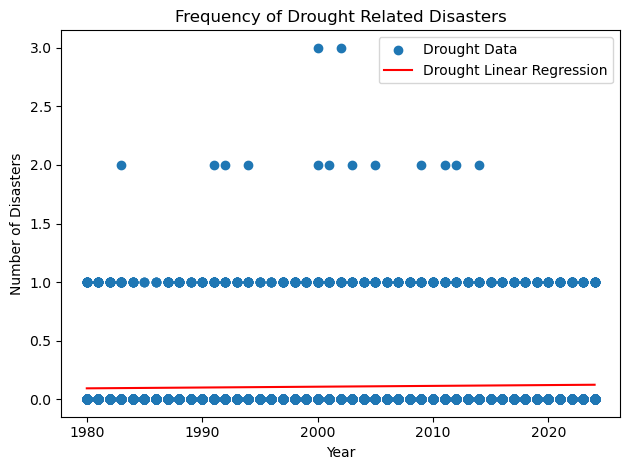

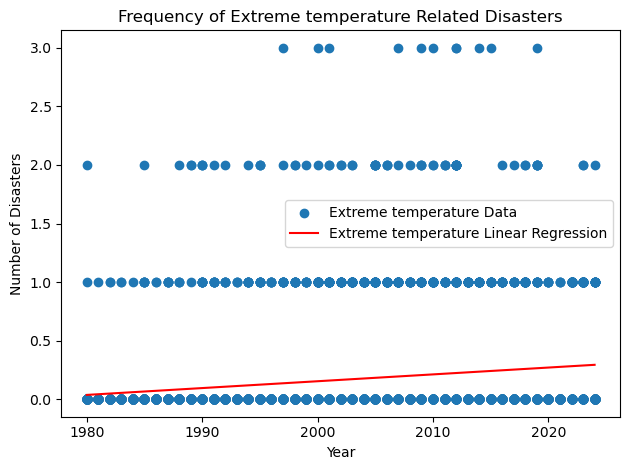

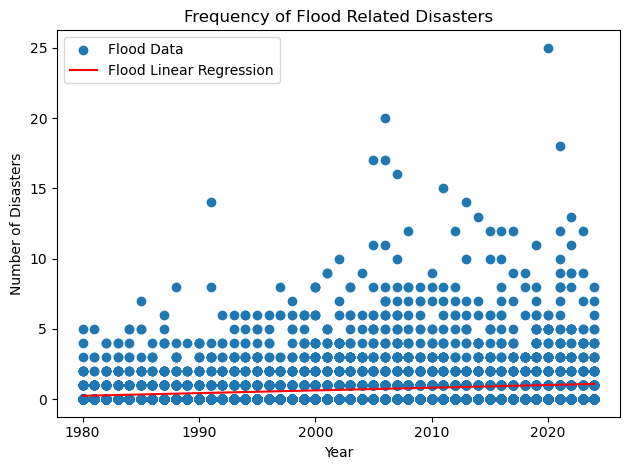

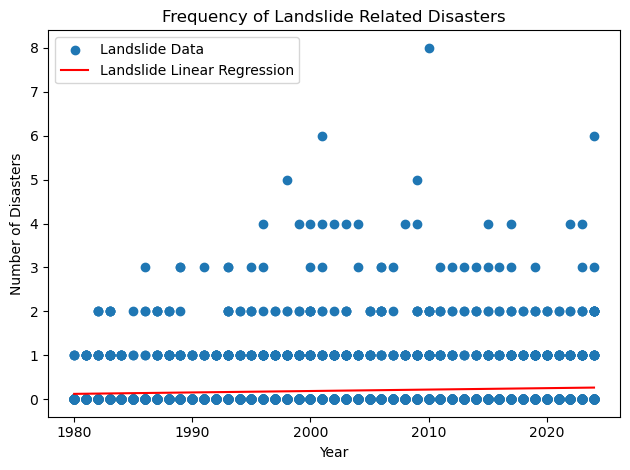

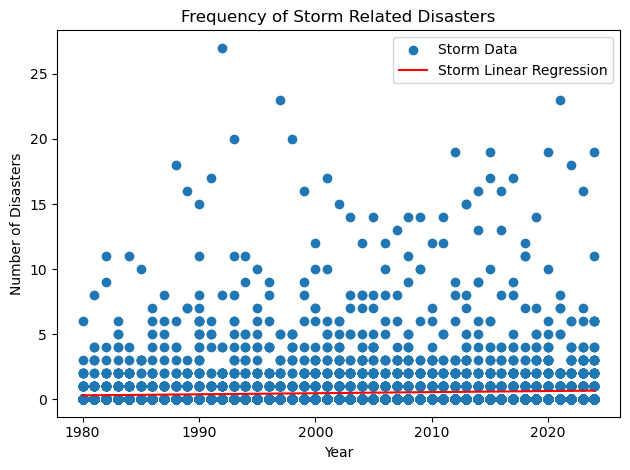

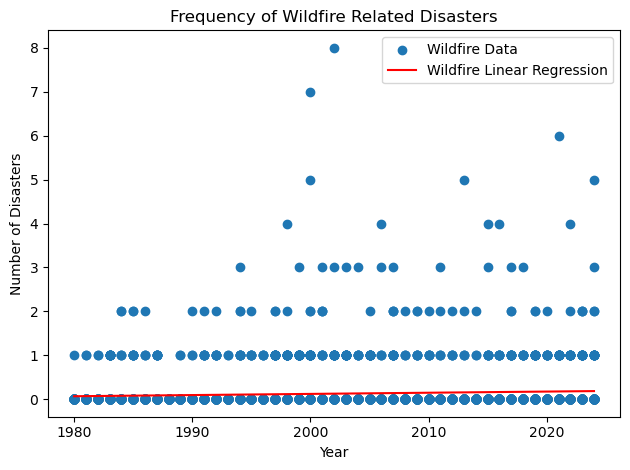

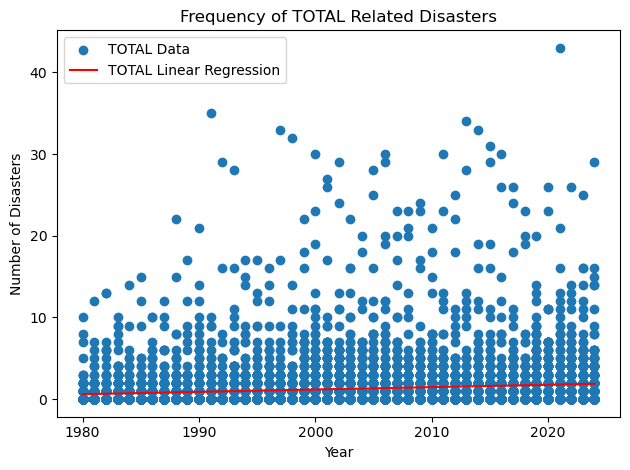

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



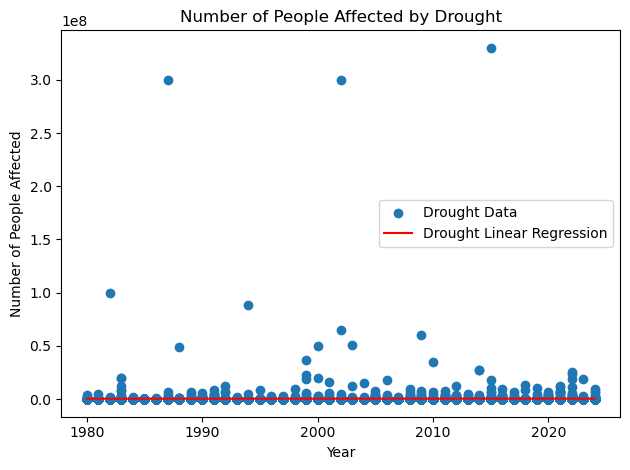

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



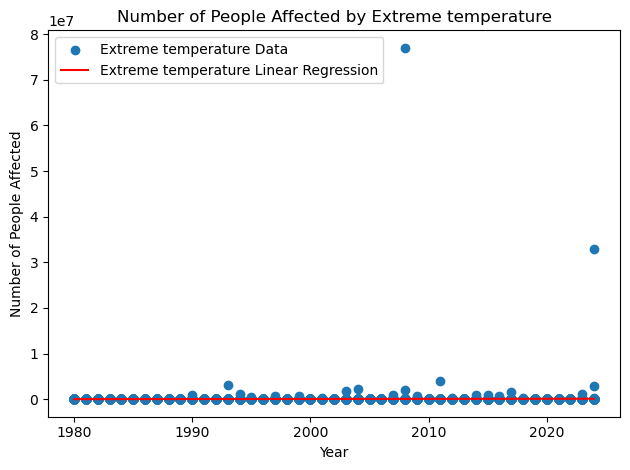

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



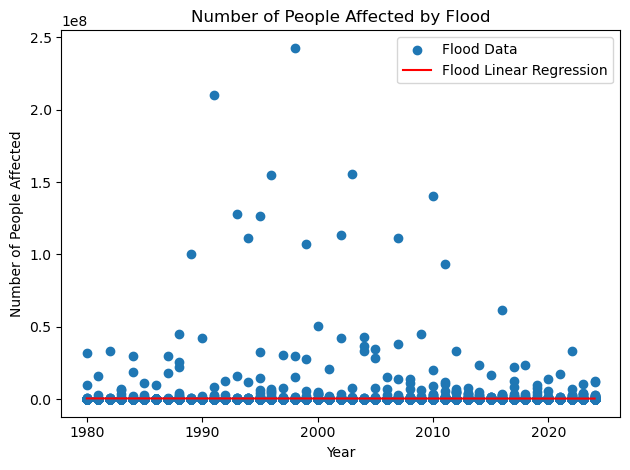

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



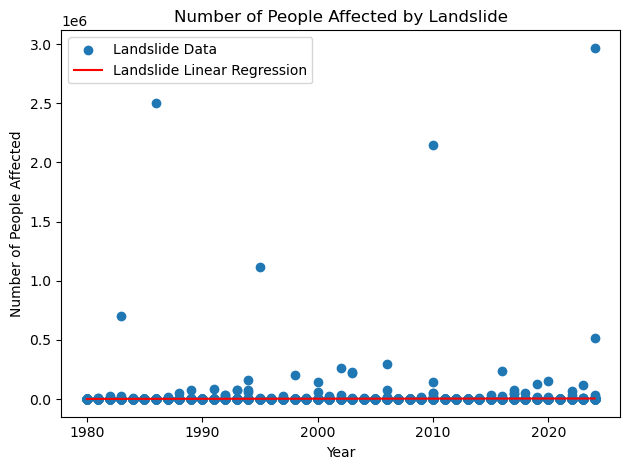

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



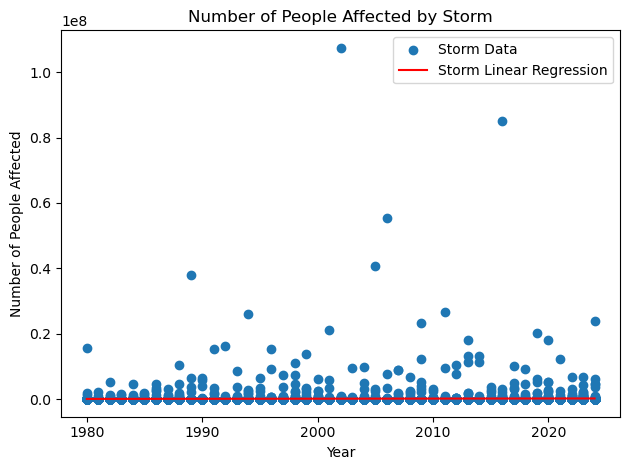

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



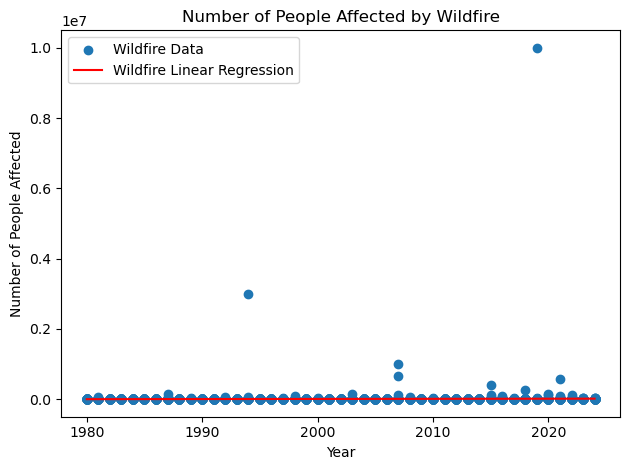

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\2233324558.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



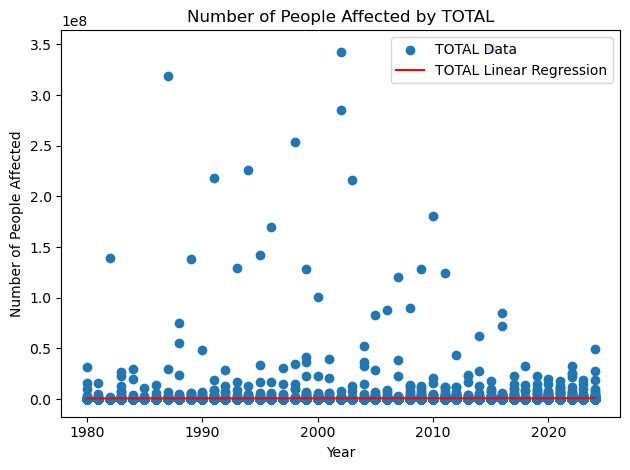

In [112]:
types = ["Drought","Extreme temperature","Flood","Landslide","Storm","Wildfire","TOTAL"]
for type_ in types:
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].mean().reset_index()
    #plt.plot(grouped['year'],grouped["value"])

    plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = selected["year"].values.reshape(-1, 1)
    y = selected["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(selected["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('Number of Disasters')
    plt.title(f'Frequency of {type_} Related Disasters')
    plt.legend()
    plt.tight_layout()
    plt.show()
for type_ in types:
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of People Affected: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].mean().reset_index()
    #plt.plot(grouped['year'],grouped["value"])

    plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = selected["year"].values.reshape(-1, 1)
    y = selected["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(selected["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('Number of People Affected')
    plt.title(f'Number of People Affected by {type_}')
    plt.legend()
    plt.tight_layout()
    plt.show()

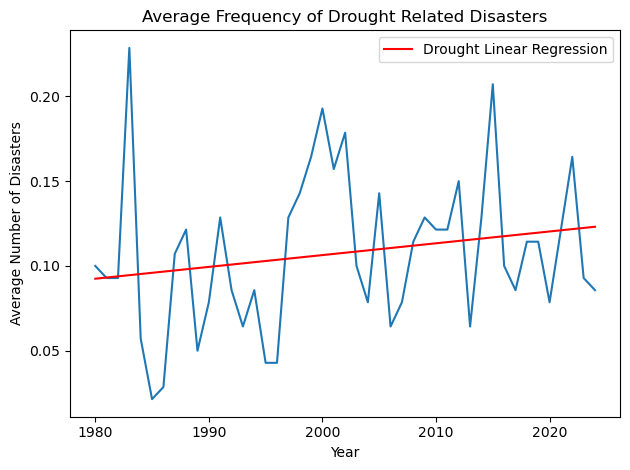

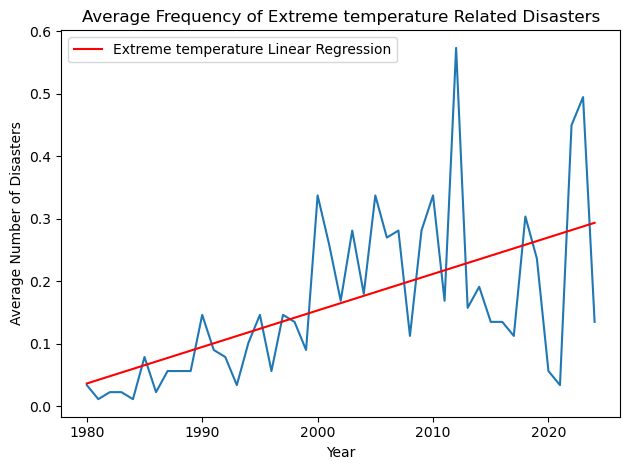

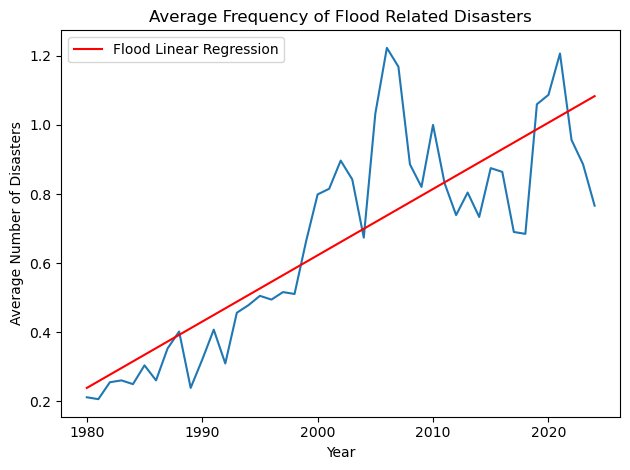

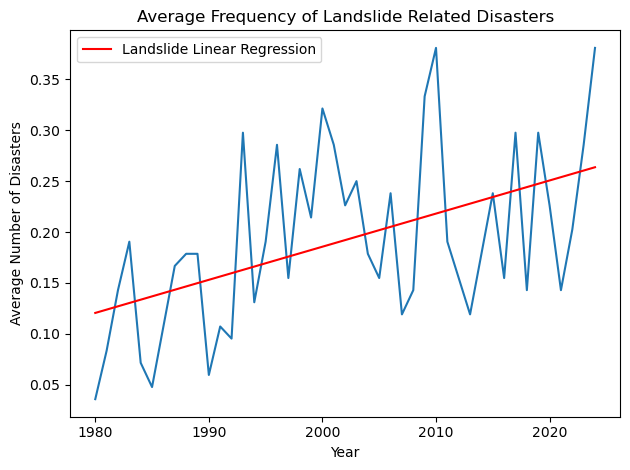

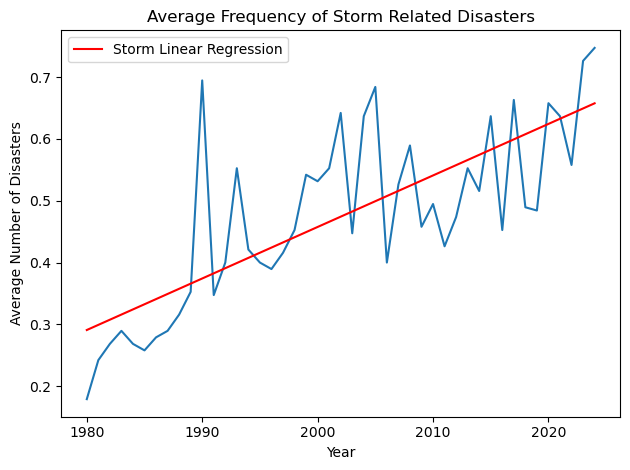

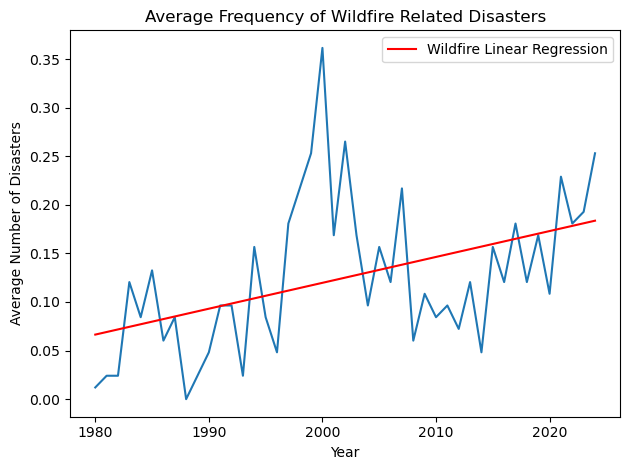

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\14302441.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



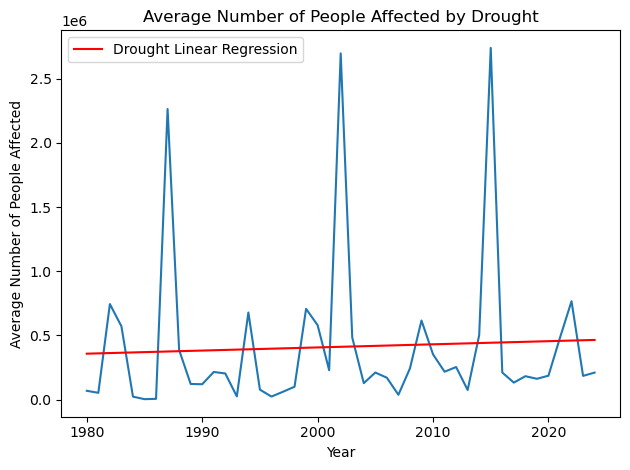

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\14302441.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



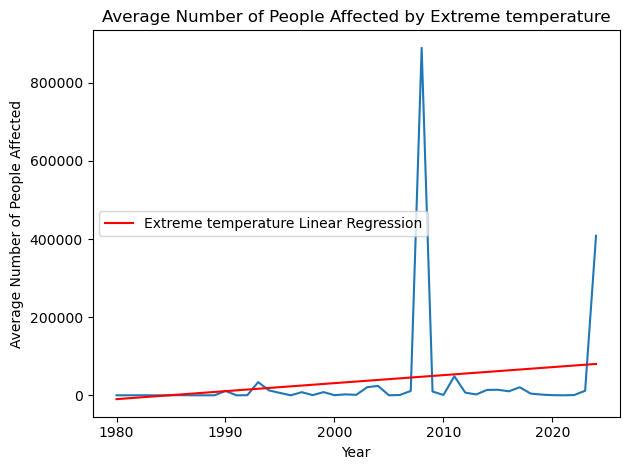

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\14302441.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



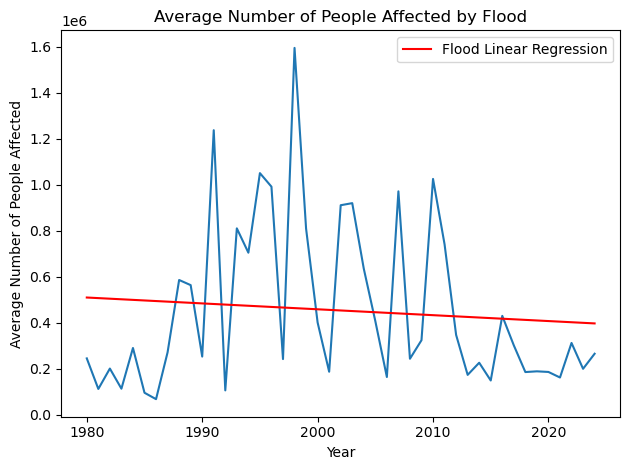

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\14302441.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



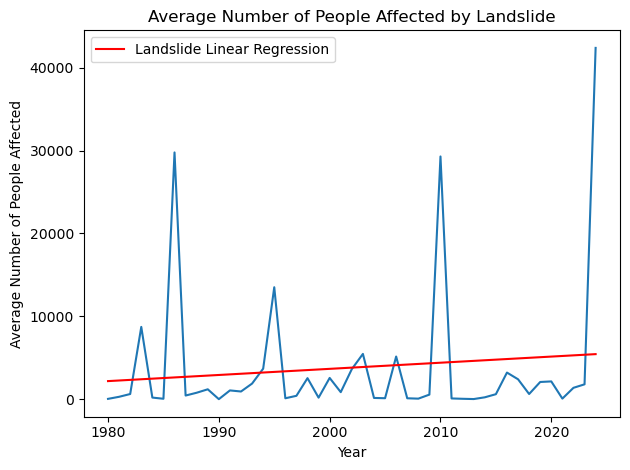

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\14302441.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



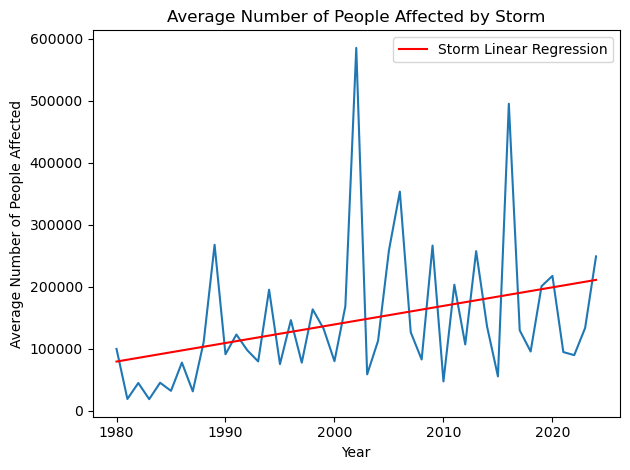

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\14302441.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



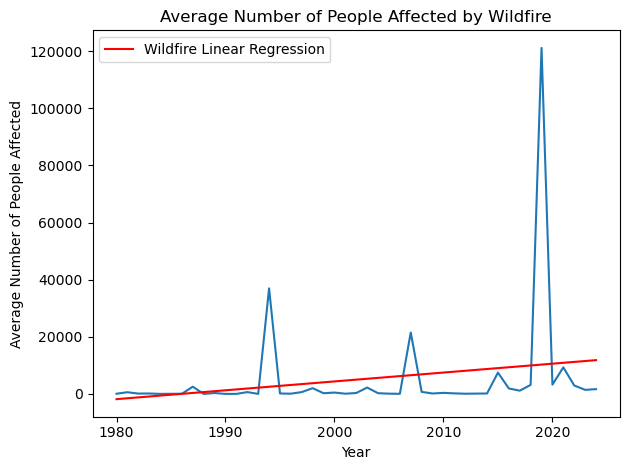

In [113]:
types = ["Drought","Extreme temperature","Flood","Landslide","Storm","Wildfire"]
for type_ in types:
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].mean().reset_index()
    plt.plot(grouped['year'],grouped["value"])

    #plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = selected["year"].values.reshape(-1, 1)
    y = selected["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(selected["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('Average Number of Disasters')
    plt.title(f'Average Frequency of {type_} Related Disasters')
    plt.legend()
    plt.tight_layout()
    plt.show()
for type_ in types:
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of People Affected: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].mean().reset_index()
    plt.plot(grouped['year'],grouped["value"])

    #plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = selected["year"].values.reshape(-1, 1)
    y = selected["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(selected["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('Average Number of People Affected')
    plt.title(f'Average Number of People Affected by {type_}')
    plt.legend()
    plt.tight_layout()
    plt.show()

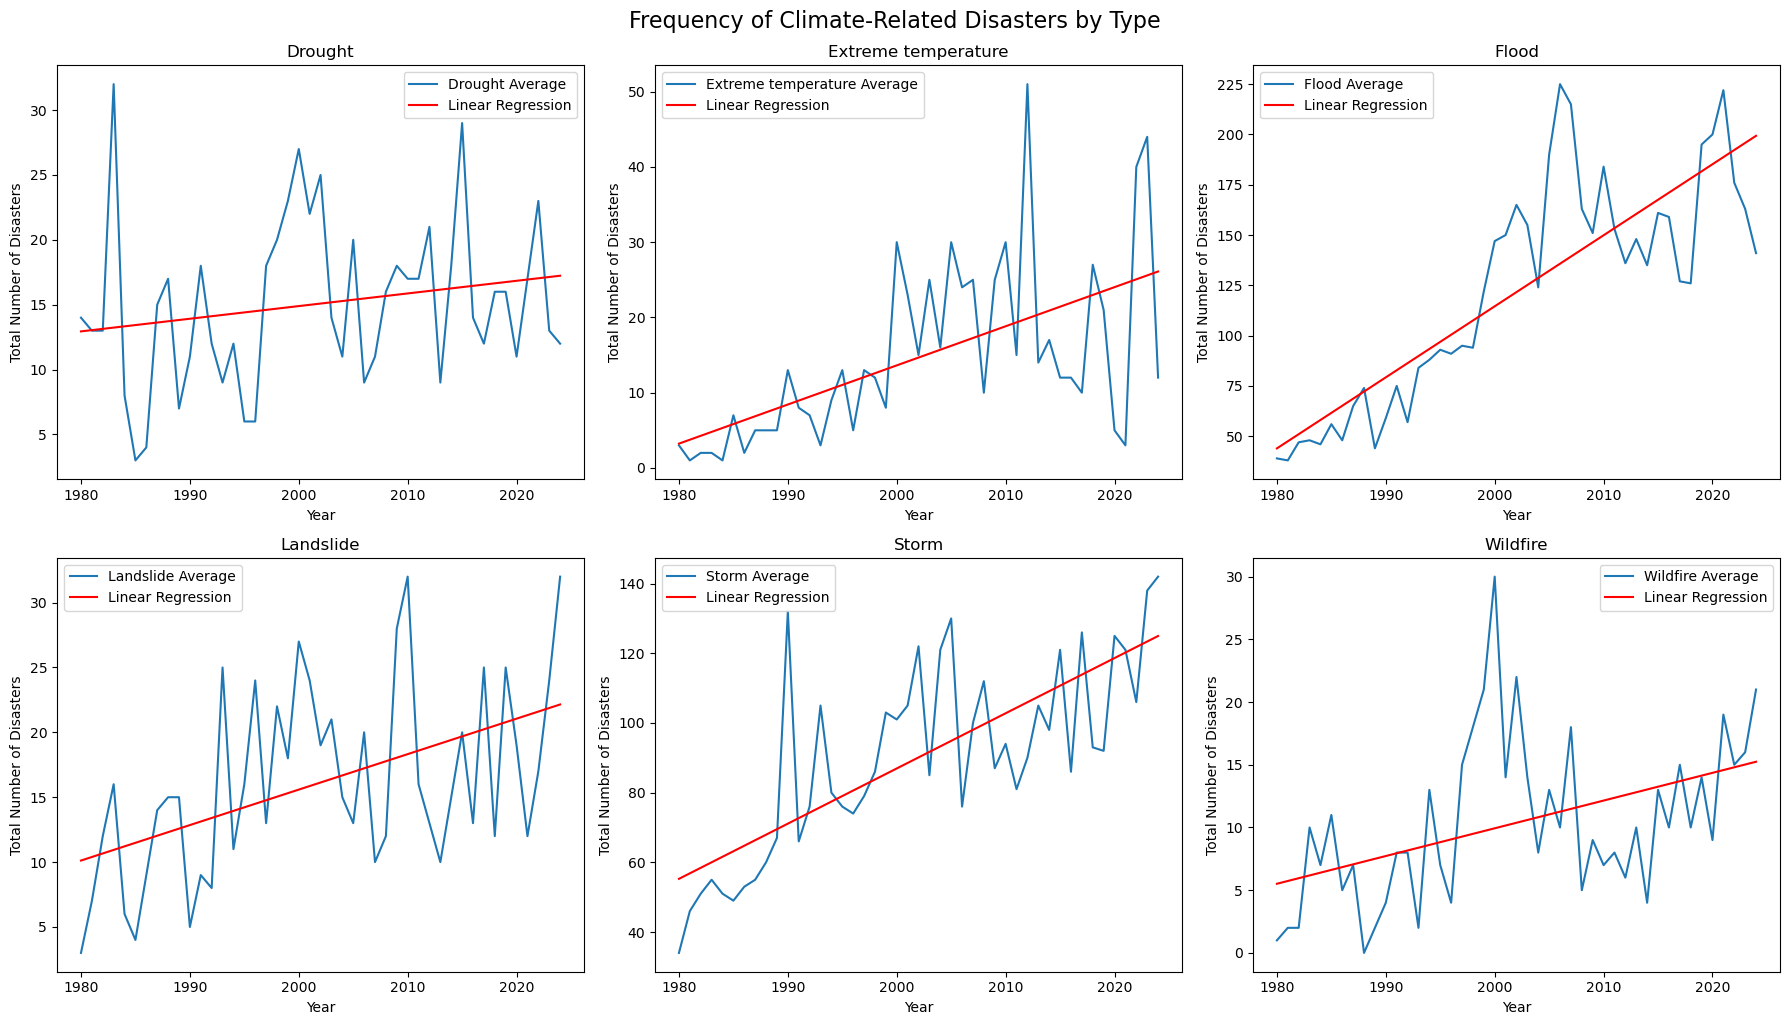

In [114]:

types = ["Drought", "Extreme temperature", "Flood", "Landslide", "Storm", "Wildfire"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows x 3 columns
axes = axes.flatten()  # Flatten to easily iterate over axes

for i, type_ in enumerate(types):
    ax = axes[i]
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].sum().reset_index()
    ax.plot(grouped['year'], grouped["value"], label=f'{type_} Average')

    # Linear regression
    X = grouped["year"].values.reshape(-1, 1)
    y = grouped["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    ax.plot(grouped["year"], y_pred, color='red', label='Linear Regression')

    ax.set_xlabel('Year')
    ax.set_ylabel('Total Number of Disasters')
    ax.set_title(f'{type_}')
    ax.legend()

plt.tight_layout()
plt.suptitle('Frequency of Climate-Related Disasters by Type', fontsize=16, y=1.02)
plt.show()


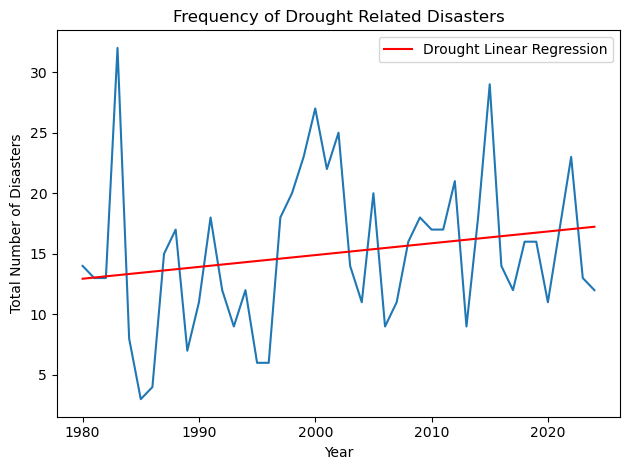

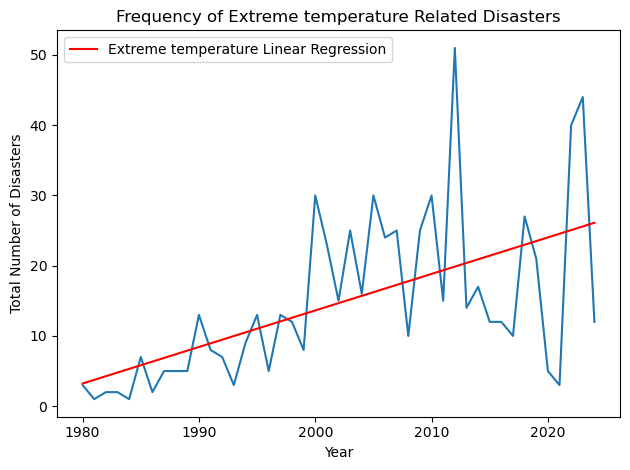

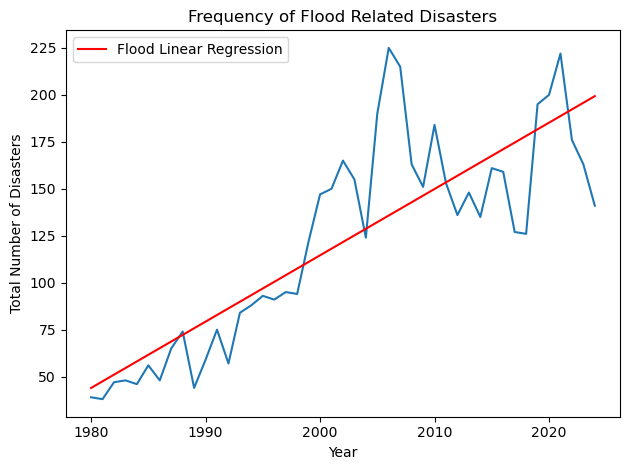

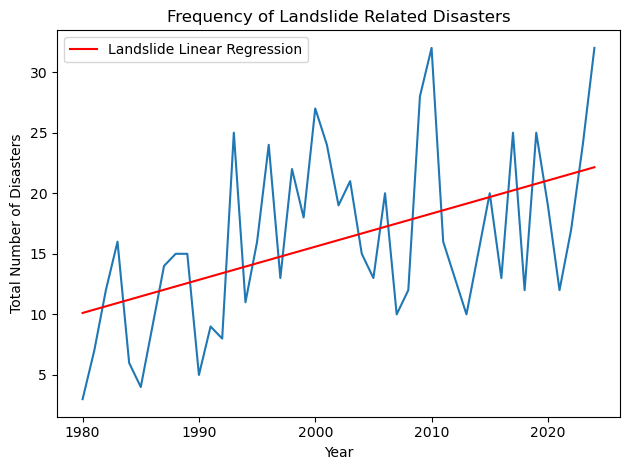

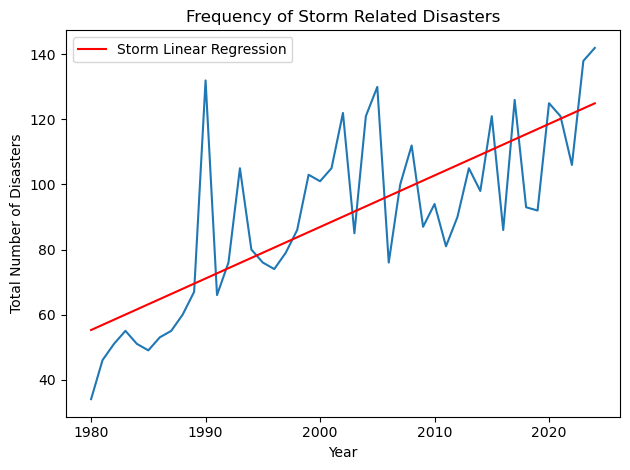

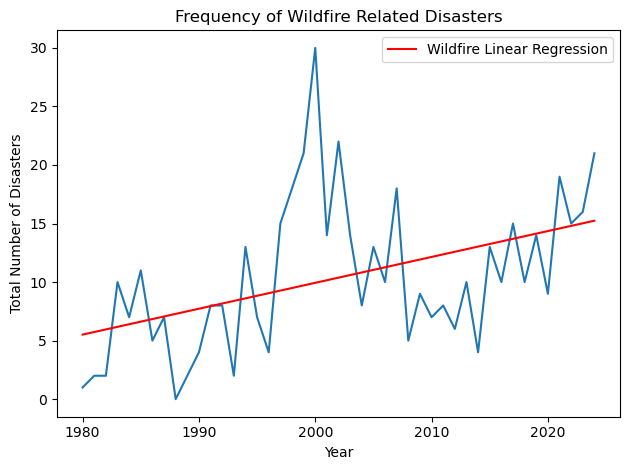

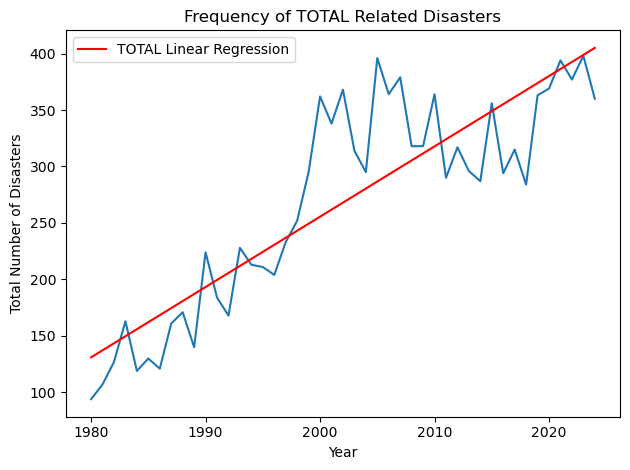

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



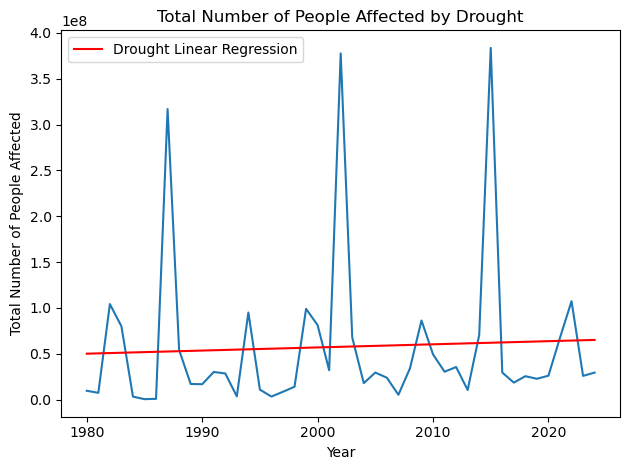

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



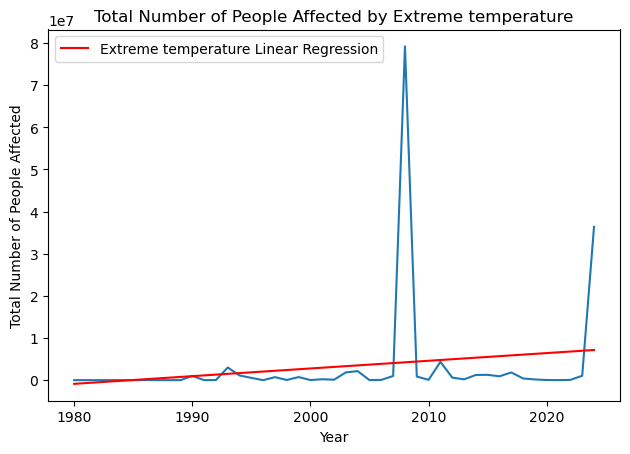

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



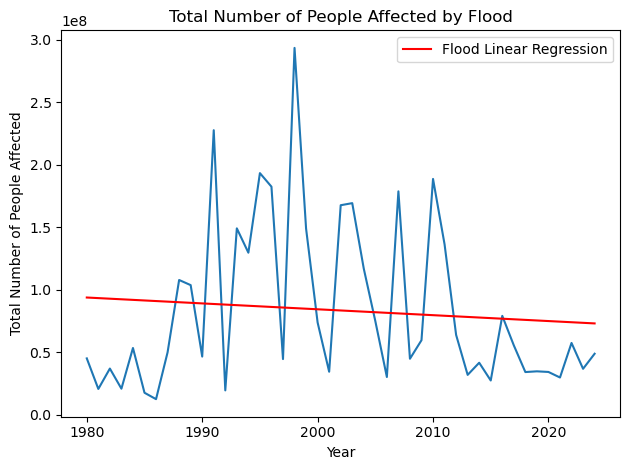

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



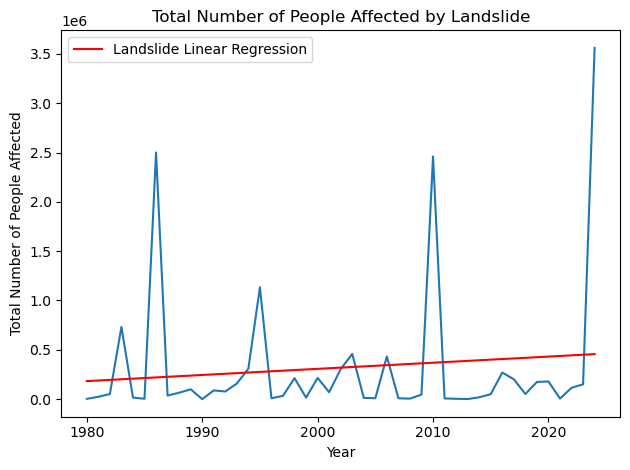

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



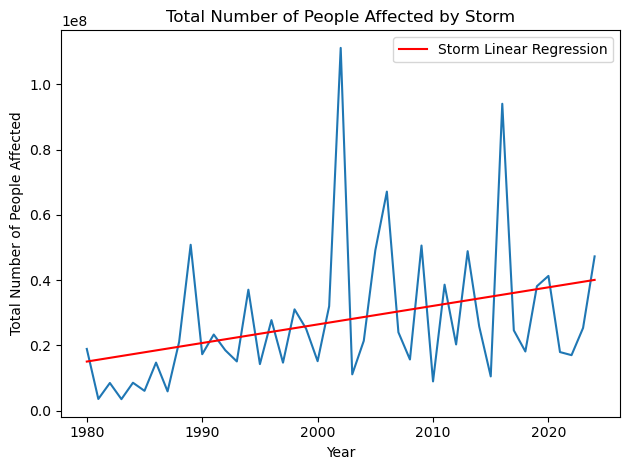

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



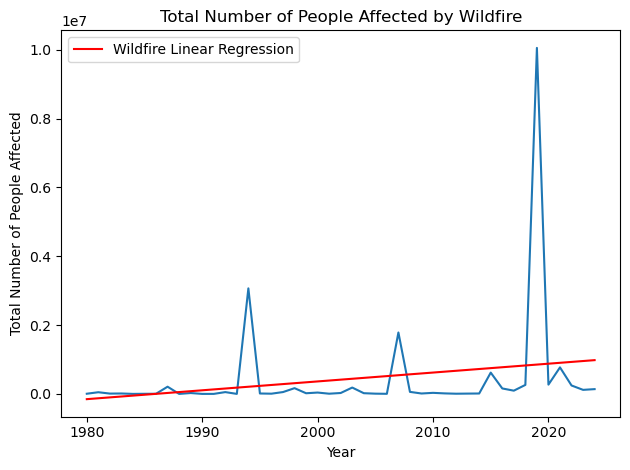

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\1346023348.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



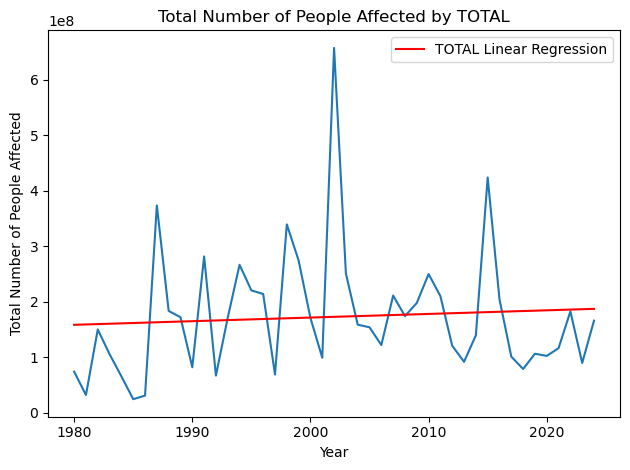

In [115]:
types = ["Drought","Extreme temperature","Flood","Landslide","Storm","Wildfire","TOTAL"]
for type_ in types:
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].sum().reset_index()
    plt.plot(grouped['year'],grouped["value"])

    #plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = grouped["year"].values.reshape(-1, 1)
    y = grouped["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(grouped["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('Total Number of Disasters')
    plt.title(f'Frequency of {type_} Related Disasters')
    plt.legend()
    plt.tight_layout()
    plt.show()
for type_ in types:
    selected = df[df["Indicator"] == f'Climate related disasters frequency, Number of People Affected: {type_}']
    selected = selected.fillna(0)
    grouped = selected.groupby("year")["value"].sum().reset_index()
    plt.plot(grouped['year'],grouped["value"])

    #plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = grouped["year"].values.reshape(-1, 1)
    y = grouped["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(grouped["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('Total Number of People Affected')
    plt.title(f'Total Number of People Affected by {type_}')
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



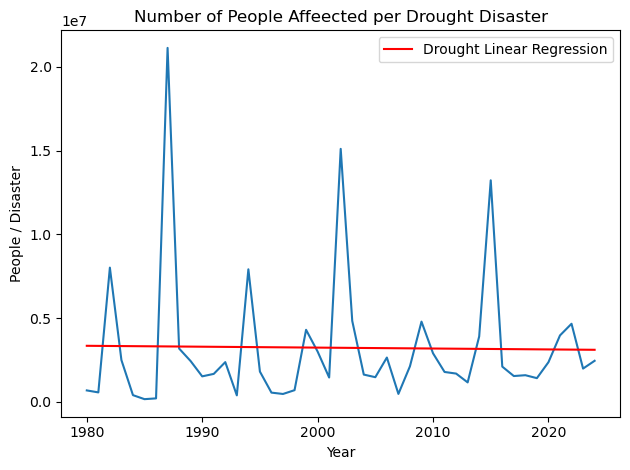

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



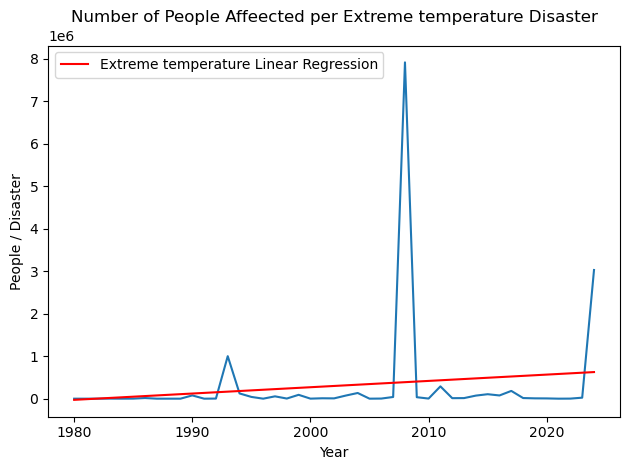

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



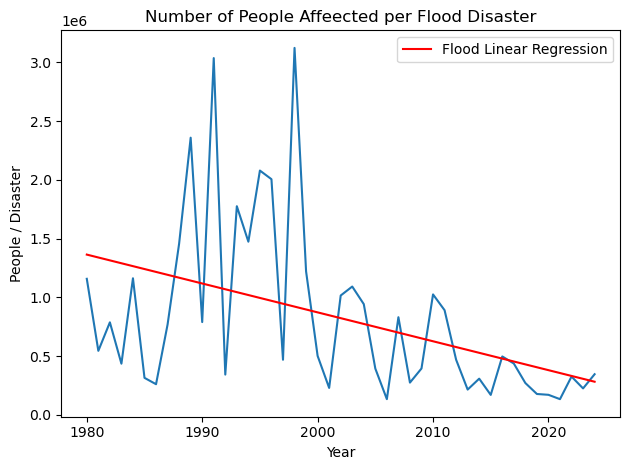

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



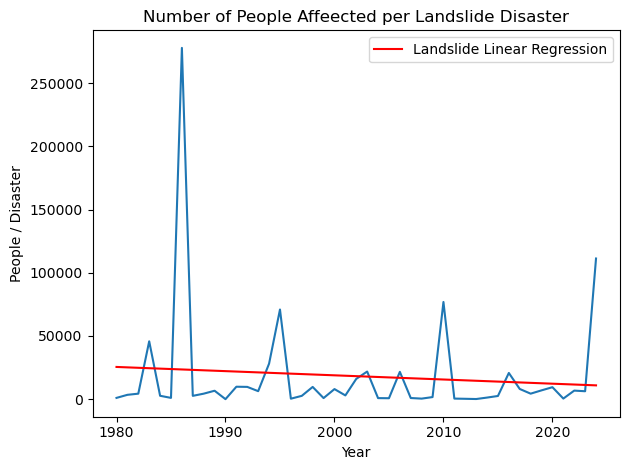

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



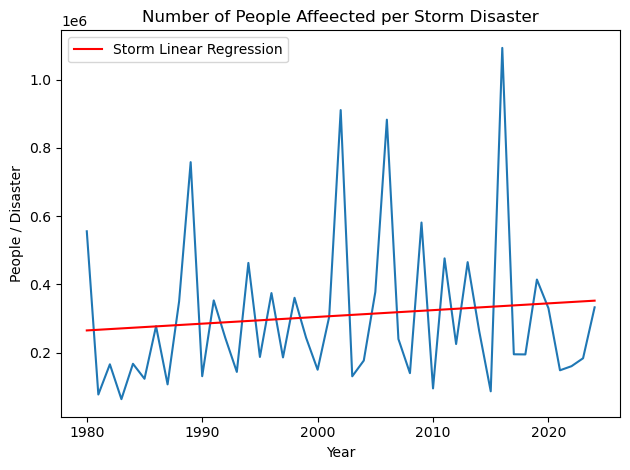

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



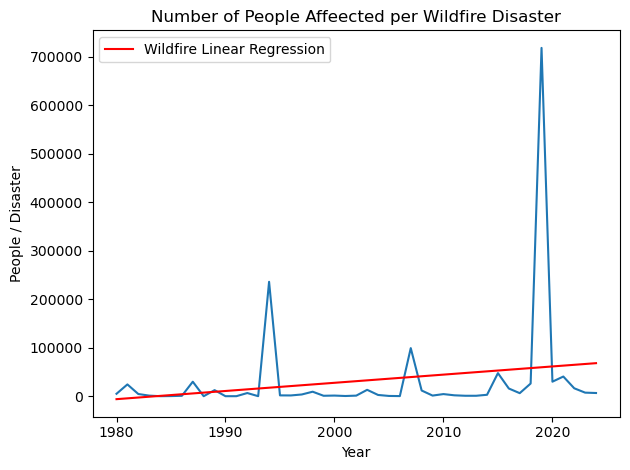

C:\Users\zcoch\AppData\Local\Temp\ipykernel_40268\3643933556.py:6: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



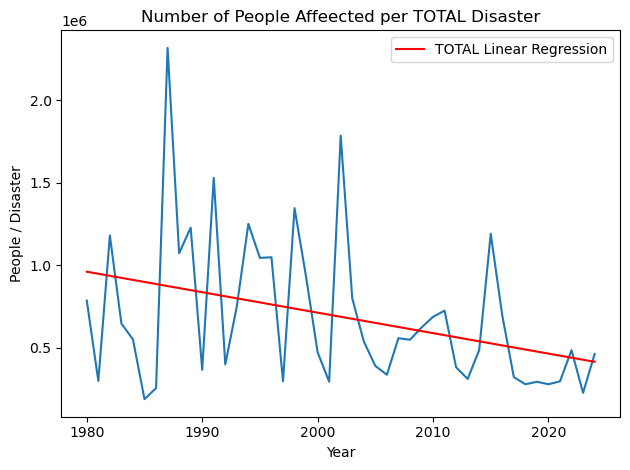

In [116]:
types = ["Drought","Extreme temperature","Flood","Landslide","Storm","Wildfire","TOTAL"]
for type_ in types:
    numDisaster = df[df["Indicator"] == f'Climate related disasters frequency, Number of Disasters: {type_}']
    numDisaster = numDisaster.fillna(0)
    numPeople = df[df["Indicator"] == f'Climate related disasters frequency, Number of People Affected: {type_}']
    numPeople = numPeople.fillna(0)
    groupedDis = numDisaster.groupby("year")["value"].sum()
    groupedPeople = numPeople.groupby("year")["value"].sum()
    peoplePerDis = (groupedPeople/groupedDis).reset_index()
    peoplePerDis=peoplePerDis.fillna(0)
    plt.plot(peoplePerDis['year'],peoplePerDis["value"])

    #plt.scatter(selected["year"], selected["value"], label=f'{type_} Data')

    X = peoplePerDis["year"].values.reshape(-1, 1)
    y = peoplePerDis["value"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(peoplePerDis["year"], y_pred, color='red', label=f'{type_} Linear Regression')

    plt.xlabel('Year')
    plt.ylabel('People / Disaster')
    plt.title(f'Number of People Affeected per {type_} Disaster')
    plt.legend()
    plt.tight_layout()
    plt.show()